In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse, urljoin
import networkx as nx
import matplotlib.pyplot as plt

def get_domain(url):
    """Extracts the domain name from a URL."""
    try:
        return urlparse(url).netloc
    except Exception:
        return None

def crawl_and_build_graph(seed_url, max_depth=2, max_pages=15):
    """
    Crawls web pages starting from a seed URL and builds a NetworkX graph 
    representing the connections between different domains.
    """
    # Initialize a Directed Graph
    G = nx.DiGraph()
    
    # Track visited URLs to avoid infinite loops
    visited_urls = set()
    # Queue for Breadth-First Search (BFS): (current_url, current_depth)
    queue = [(seed_url, 0)]
    
    pages_crawled = 0
    headers = {'User-Agent': 'Mozilla/5.0 (KnowledgeGraphBot/1.0)'}

    print(f"Starting crawl from: {seed_url}\n")

    while queue and pages_crawled < max_pages:
        current_url, depth = queue.pop(0)

        if current_url in visited_urls or depth > max_depth:
            continue

        print(f"Crawling [{pages_crawled + 1}/{max_pages}]: {current_url} (Depth: {depth})")
        visited_urls.add(current_url)
        pages_crawled += 1

        try:
            response = requests.get(current_url, headers=headers, timeout=5)
            # Only parse HTML content
            if 'text/html' not in response.headers.get('Content-Type', ''):
                continue
                
            soup = BeautifulSoup(response.text, 'html.parser')
            source_domain = get_domain(current_url)

            if not source_domain:
                continue

            # Find all anchor tags with hyperlinks
            for anchor in soup.find_all('a', href=True):
                href = anchor['href']
                # Resolve relative URLs (e.g., /about -> https://example.com/about)
                full_url = urljoin(current_url, href)
                target_domain = get_domain(full_url)

                # We want to map connections between different domains/concepts
                if target_domain and target_domain != source_domain:
                    # Add edge to the graph: Source Domain -> Target Domain
                    if G.has_edge(source_domain, target_domain):
                        G[source_domain][target_domain]['weight'] += 1
                    else:
                        G.add_edge(source_domain, target_domain, weight=1)

                    # FIXED: Removed the stray word "Packs"
                    if full_url not in visited_urls and depth < max_depth:
                        queue.append((full_url, depth + 1))

        except requests.exceptions.RequestException as e:
            print(f"Failed to crawl {current_url}: {e}")
            continue

    return G

def visualize_knowledge_graph(G):
    """Visualizes the NetworkX graph using Matplotlib."""
    if len(G.nodes) == 0:
        print("The graph is empty. No connections found to visualize.")
        return

    plt.figure(figsize=(12, 12))
    plt.title("Web-Traversing Domain Knowledge Graph", fontsize=16, fontweight='bold')

    # Layout algorithm for positioning nodes
    pos = nx.spring_layout(G, k=0.5, iterations=50)

    # Node scaling based on how many connections they have (degree)
    node_sizes = [v * 300 + 100 for v in dict(G.degree()).values()]

    # Draw nodes, edges, and labels
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', edgecolors='navy')
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6, edge_color='gray', arrows=True, arrowsize=15)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_family='sans-serif')

    plt.axis('off')
    plt.tight_layout()
    print("\nDisplaying knowledge graph...")
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    START_URL = "https://news.ycombinator.com/" 
    
    # Build the graph
    web_graph = crawl_and_build_graph(START_URL, max_depth=1, max_pages=10)
    
    # Visualize the results
    visualize_knowledge_graph(web_graph)

Starting crawl from: https://news.ycombinator.com/

Crawling [1/10]: https://news.ycombinator.com/ (Depth: 0)
Crawling [2/10]: https://innovativegenomics.org/news/crispr-technique-selectively-shreds-cancer-cells/ (Depth: 1)
Crawling [3/10]: https://blog.miguelgrinberg.com/post/i-am-not-a-reverse-centaur (Depth: 1)
Crawling [4/10]: https://ikyle.me/blog/2026/how-to-setup-a-local-coding-agent-on-macos (Depth: 1)
Crawling [5/10]: https://piwodlaiwo.github.io/pirates/ (Depth: 1)
Crawling [6/10]: https://sgaud.com/texts/pdf (Depth: 1)
Crawling [7/10]: https://envs.net/~volpe/blog/posts/reduce-slop.html (Depth: 1)
Crawling [8/10]: https://www.pgedge.com/blog/looking-forward-to-postgres-19-its-about-time (Depth: 1)
Crawling [9/10]: https://twitter.com/jsrailton/status/2064661778978533571 (Depth: 1)
Crawling [10/10]: https://yalereview.org/article/sheila-liming-the-end-of-books (Depth: 1)

Displaying knowledge graph...


<Figure size 1200x1200 with 1 Axes>

In [2]:
import requests

class MCUGraphBuilder:
    def __init__(self):
        # Official Wikipedia API Endpoint
        self.api_url = "https://en.wikipedia.org/w/api.php"
        
        # Best practice: Provide a clear User-Agent to avoid getting throttled
        self.headers = {
            "User-Agent": "MCUKnowledgeGraphBuilder/1.0 (contact: your_email@example.com)"
        }

    def fetch_mcu_characters(self, limit=50):
        """
        Queries the Wikipedia API to fetch a list of titles belonging to the
        'Marvel Cinematic Universe characters' category.
        
        :param limit: Maximum number of character titles to fetch (Max 500 for standard users)
        :return: A list of string titles representing individual MCU characters/pages.
        """
        # Define API parameters for exploring a category list
        params = {
            "action": "query",
            "list": "categorymembers",
            "cmtitle": "Category:Marvel Cinematic Universe characters",
            "cmlimit": limit,
            "format": "json"
        }

        character_titles = []

        try:
            response = requests.get(self.api_url, headers=self.headers, params=params, timeout=10)
            response.raise_for_status() # Raise error for bad status codes (404, 500, etc.)
            
            data = response.json()
            
            # Extract the members list from the nested JSON payload
            members = data.get("query", {}).get("categorymembers", [])
            
            for member in members:
                # Filter out subcategories (ns=14) or files (ns=6) to ensure we only get articles (ns=0)
                if member.get("ns") == 0:
                    character_titles.append(member.get("title"))
                    
        except requests.exceptions.RequestException as e:
            print(f"Error connecting to Wikipedia API: {e}")
            
        return character_titles

# --- Example Execution ---
if __name__ == "__main__":
    # Instantiate the builder
    builder = MCUGraphBuilder()
    
    print("Fetching MCU character titles from Wikipedia...")
    mcu_characters = builder.fetch_mcu_characters(limit=30)
    
    print(f"\nSuccessfully retrieved {len(mcu_characters)} character profiles:")
    for idx, title in enumerate(mcu_characters, 1):
        print(f"{idx}. {title}")

Fetching MCU character titles from Wikipedia...

Successfully retrieved 30 character profiles:
1. Yelena Belova (Marvel Cinematic Universe)
2. Kate Bishop (Marvel Cinematic Universe)
3. Blade (New Line franchise character)
4. Frank Castle (Marvel Cinematic Universe)
5. Death (Marvel Cinematic Universe)
6. Wilson Fisk (Marvel Cinematic Universe)
7. Agatha Harkness (Marvel Cinematic Universe)
8. J. Jonah Jameson (2002 film series character)
9. Jessica Jones (Marvel Cinematic Universe)
10. Daisy Johnson (Marvel Cinematic Universe)
11. Tyrone Johnson and Tandy Bowen (Marvel Cinematic Universe)
12. Kamala Khan (Marvel Cinematic Universe)
13. Logan (film character)
14. Maya Lopez (Marvel Cinematic Universe)
15. Magneto (film character)
16. Matt Murdock (Marvel Cinematic Universe)
17. Mystique (film character)
18. Otto Octavius (film character)
19. Norman Osborn (2002 film series character)
20. Peter Parker (The Amazing Spider-Man film series)
21. Peter Parker (2002 film series character)
22.

In [3]:
import requests

class MCUGraphBuilder:
    def __init__(self):
        # Official Wikipedia API Endpoint
        self.api_url = "https://en.wikipedia.org/w/api.php"
        
        # Best practice: Provide a clear User-Agent to avoid getting throttled
        self.headers = {
            "User-Agent": "MCUKnowledgeGraphBuilder/1.0 (contact: your_email@example.com)"
        }

    def fetch_mcu_characters(self, limit=50):
        """
        Queries the Wikipedia API to fetch a list of titles belonging to the
        'Marvel Cinematic Universe characters' category.
        """
        params = {
            "action": "query",
            "list": "categorymembers",
            "cmtitle": "Category:Marvel Cinematic Universe characters",
            "cmlimit": limit,
            "format": "json"
        }

        character_titles = []
        try:
            response = requests.get(self.api_url, headers=self.headers, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            members = data.get("query", {}).get("categorymembers", [])
            for member in members:
                if member.get("ns") == 0:  # Only main articles
                    character_titles.append(member.get("title"))
        except requests.exceptions.RequestException as e:
            print(f"Error fetching characters: {e}")
            
        return character_titles

    def get_links(self, page_title, max_links=100):
        """
        Fetches all internal Wikipedia links pointing to other main articles 
        from a given Wikipedia page title.
        
        :param page_title: The title of the Wikipedia page to parse.
        :param max_links: Maximum number of links to retrieve.
        :return: A list of string titles that this page links to.
        """
        # Define API parameters for retrieving outbound links
        params = {
            "action": "query",
            "titles": page_title,
            "prop": "links",
            "plnamespace": 0,      # CRITICAL: Only fetch links to main articles (ignores templates, categories, help pages)
            "pllimit": "max",      # Tells Wikipedia to return the maximum links per page (up to 500)
            "format": "json"
        }

        links = []
        
        try:
            while True:
                response = requests.get(self.api_url, headers=self.headers, params=params, timeout=10)
                response.raise_for_status()
                data = response.json()
                
                # Navigate the nested JSON structure: query -> pages -> (page_id string) -> links
                pages = data.get("query", {}).get("pages", {})
                
                for page_id, page_data in pages.items():
                    page_links = page_data.get("links", [])
                    for link_obj in page_links:
                        links.append(link_obj.get("title"))
                        # Stop early if we hit our requested link ceiling
                        if len(links) >= max_links:
                            return links[:max_links]
                
                # Wikipedia uses a pagination system. If a page has more links than pllimit,
                # it returns a 'continue' token. If it exists, we loop again with the new token.
                if "continue" in data:
                    params.update(data["continue"])
                else:
                    break  # No more links left to fetch
                    
        except requests.exceptions.RequestException as e:
            print(f"Error fetching links for '{page_title}': {e}")
            
        return links

# --- Example Execution ---
if __name__ == "__main__":
    builder = MCUGraphBuilder()
    
    # Let's pick a popular MCU character page to parse
    target_character = "Tony Stark (Marvel Cinematic Universe)"
    
    print(f"Fetching internal links from '{target_character}'...")
    internal_links = builder.get_links(target_character, max_links=25)
    
    print(f"\nFound {len(internal_links)} standard Wikipedia article connections:")
    for idx, link in enumerate(internal_links, 1):
        print(f" -> {link}")

Fetching internal links from 'Tony Stark (Marvel Cinematic Universe)'...

Found 25 standard Wikipedia article connections:
 -> /Film
 -> 14th Empire Awards
 -> 18th Critics' Choice Awards
 -> 18th Empire Awards
 -> 19th Critics' Choice Awards
 -> 2008 Scream Awards
 -> 2008 Teen Choice Awards
 -> 2009 MTV Movie Awards
 -> 2010 Scream Awards
 -> 2010 Teen Choice Awards
 -> 2011 Kids' Choice Awards
 -> 2011 MTV Movie Awards
 -> 2012 Teen Choice Awards
 -> 2013 Kids' Choice Awards
 -> 2013 MTV Movie Awards
 -> 2013 Teen Choice Awards
 -> 2014 Kids' Choice Awards
 -> 2014 MTV Movie Awards
 -> 2015 Teen Choice Awards
 -> 2016 Kids' Choice Awards
 -> 2016 MTV Movie Awards
 -> 2016 Teen Choice Awards
 -> 2017 Kids' Choice Awards
 -> 2018 Teen Choice Awards
 -> 2019 Kids' Choice Awards


Scouting official MCU character directory from Wikipedia...
Loaded 30 characters into the scope whitelist.

Beginning BFS Web-Traversal...
 Processing Layer 0 -> Crawling: 'Mystique (film character)'
 Processing Layer 0 -> Crawling: 'Wilson Fisk (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Matt Murdock (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Maya Lopez (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Marc Spector (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Hope van Dyne'
 Processing Layer 0 -> Crawling: 'Agatha Harkness (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Peter Parker (2002 film series character)'
 Processing Layer 0 -> Crawling: 'Kate Bishop (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Frank Castle (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Shuri (Marvel Cinematic Universe)'
 Processing Layer 0 -> Crawling: 'Claire Temple (Marvel Cinematic Universe

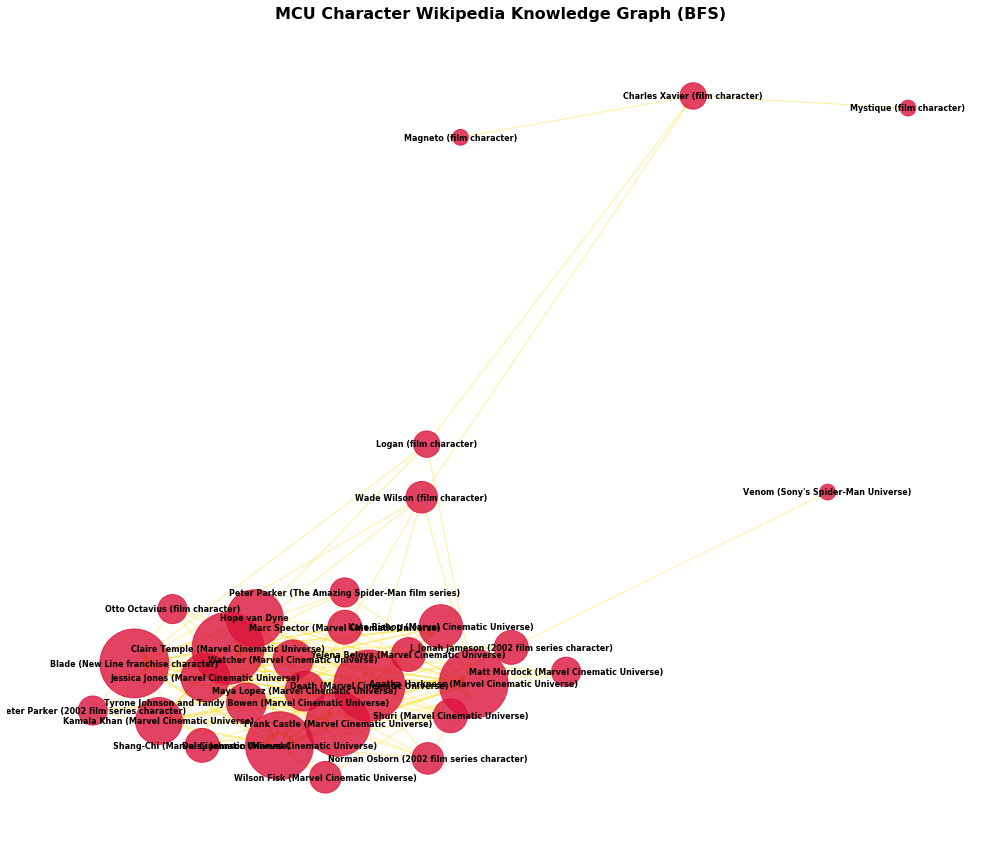

In [4]:
import requests
import networkx as nx
import matplotlib.pyplot as plt

class MCUGraphBuilder:
    def __init__(self):
        self.api_url = "https://en.wikipedia.org/w/api.php"
        self.headers = {
            "User-Agent": "MCUKnowledgeGraphBuilder/1.0 (contact: your_email@example.com)"
        }

    def fetch_mcu_characters(self, limit=50):
        """Queries Wikipedia to get official MCU character page titles."""
        params = {
            "action": "query",
            "list": "categorymembers",
            "cmtitle": "Category:Marvel Cinematic Universe characters",
            "cmlimit": limit,
            "format": "json"
        }
        character_titles = set() # Using a set for O(1) lookups later
        try:
            response = requests.get(self.api_url, headers=self.headers, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            members = data.get("query", {}).get("categorymembers", [])
            for member in members:
                if member.get("ns") == 0:
                    character_titles.add(member.get("title"))
        except requests.exceptions.RequestException as e:
            print(f"Error fetching character registry: {e}")
            
        return character_titles

    def get_links(self, page_title, max_links=100):
        """Fetches internal main-space Wikipedia links from a given page title."""
        params = {
            "action": "query",
            "titles": page_title,
            "prop": "links",
            "plnamespace": 0,
            "pllimit": "max",
            "format": "json"
        }
        links = []
        try:
            while True:
                response = requests.get(self.api_url, headers=self.headers, params=params, timeout=10)
                response.raise_for_status()
                data = response.json()
                pages = data.get("query", {}).get("pages", {})
                for page_id, page_data in pages.items():
                    page_links = page_data.get("links", [])
                    for link_obj in page_links:
                        links.append(link_obj.get("title"))
                        if len(links) >= max_links:
                            return links[:max_links]
                if "continue" in data:
                    params.update(data["continue"])
                else:
                    break
        except requests.exceptions.RequestException as e:
            # Silently log errors for individual pages to keep the BFS traversal going
            print(f"  [Warning] Could not fetch links for '{page_title}': {e}")
            
        return links

    def build_graph(self, max_characters=30, max_depth=1):
        """
        Uses Breadth-First Search (BFS) to traverse and build a NetworkX graph 
        of connections restricted strictly to MCU characters.
        
        :param max_characters: Number of initial MCU character seeds to fetch.
        :param max_depth: How deep the BFS should crawl (0 = only nodes, 1 = immediate links, etc.)
        :return: A populated networkx.DiGraph object
        """
        # 1. Fetch our universe scope (acts as our node validation whitelist)
        print(f"Scouting official MCU character directory from Wikipedia...")
        mcu_character_registry = self.fetch_mcu_characters(limit=max_characters)
        print(f"Loaded {len(mcu_character_registry)} characters into the scope whitelist.\n")

        # Initialize Directed Graph
        G = nx.DiGraph()
        G.add_nodes_from(mcu_character_registry)

        # 2. Setup BFS tracking structures
        # Queue format: (page_title, current_depth)
        queue = [(char, 0) for char in mcu_character_registry]
        visited = set()

        print("Beginning BFS Web-Traversal...")
        while queue:
            current_page, depth = queue.pop(0)

            # Guard clauses: Skip if already handled or if we are exceeding our depth ceiling
            if current_page in visited or depth >= max_depth:
                continue
            
            print(f" Processing Layer {depth} -> Crawling: '{current_page}'")
            visited.add(current_page)

            # Get out-bound hyperlinks from this page
            outbound_links = self.get_links(current_page, max_links=200)

            for target in outbound_links:
                # DOMAIN FILTER: Only draw lines to pages that are also in our MCU character registry
                if target in mcu_character_registry and target != current_page:
                    G.add_edge(current_page, target)
                    
                    # If the target character hasn't been crawled yet, add it to the BFS queue
                    if target not in visited:
                        queue.append((target, depth + 1))

        return G

    def visualize(self, G):
        """Helper to draw the resulting Network Graph."""
        plt.figure(figsize=(14, 12))
        plt.title("MCU Character Wikipedia Knowledge Graph (BFS)", fontsize=16, fontweight='bold')
        
        # Calculate positions using force-directed layout
        pos = nx.spring_layout(G, k=0.4, iterations=40)
        
        # Style nodes dynamically based on connection density (Degree)
        node_sizes = [v * 150 + 100 for v in dict(G.degree()).values()]
        
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='crimson', alpha=0.8)
        nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.4, edge_color='gold', arrows=True)
        nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif', font_weight='bold')
        
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# --- Run the Crawler ---
if __name__ == "__main__":
    builder = MCUGraphBuilder()
    
    # max_depth=1 builds connections among the initial 40 characters fetched. 
    # Increasing depth to 2 will let it traverse links *found* on those pages.
    mcu_network = builder.build_graph(max_characters=40, max_depth=1)
    
    print(f"\nGraph generation complete!")
    print(f"Total Nodes (Characters): {mcu_network.number_of_nodes()}")
    print(f"Total Edges (Connections): {mcu_network.number_of_edges()}")
    
    # Visualize the results
    builder.visualize(mcu_network)

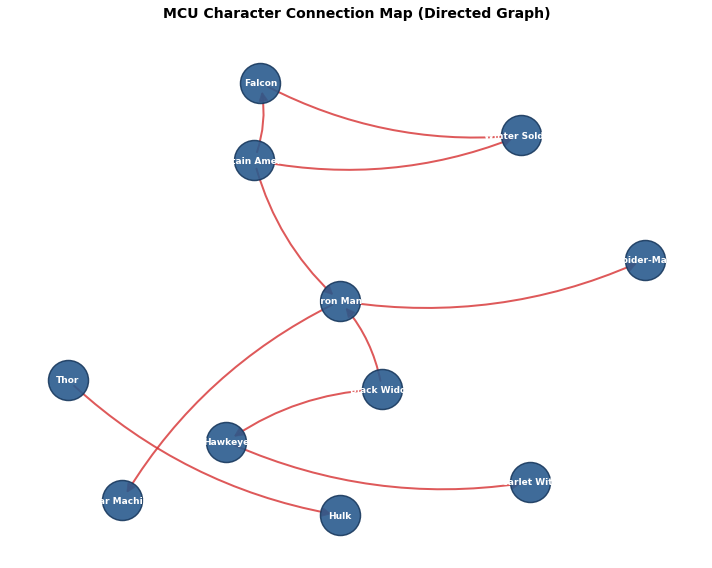

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def create_mcu_directed_graph():
    """Creates a directed graph representing connections between characters."""
    # Initialize a Directed Graph (DiGraph)
    G = nx.DiGraph()

    # Define nodes (characters)
    characters = [
        "Iron Man", "Spider-Man", "War Machine", 
        "Captain America", "Winter Soldier", "Falcon", 
        "Black Widow", "Hawkeye", "Thor", "Hulk"
    ]
    G.add_nodes_from(characters)

    # Define directed edges (Source -> Target)
    # The direction represents "influences", "mentors", or "is allied with"
    connections = [
        ("Iron Man", "Spider-Man"),       # Stark mentored Peter
        ("Iron Man", "War Machine"),      # Longtime allies
        ("Captain America", "Winter Soldier"),
        ("Captain America", "Falcon"),
        ("Captain America", "Iron Man"),  # Core Avengers relationship
        ("Black Widow", "Hawkeye"),       # Deep history / Budapest
        ("Black Widow", "Iron Man"),
        ("Falcon", "Winter Soldier"),
        ("Thor", "Hulk"),                 # Gladiators in Ragnarok
        ("Hawkeye", "Scarlet Witch"),     # Mentored her in Age of Ultron
    ]
    G.add_edges_from(connections)
    
    return G

def visualize_directed_graph(G):
    """Configures and displays the directed graph with custom styling."""
    # Set up the plotting window size
    plt.figure(figsize=(10, 8))
    plt.title("MCU Character Connection Map (Directed Graph)", fontsize=14, fontweight='bold', pad=20)

    # Calculate layout positions using a force-directed layout
    # 'k' controls the optimal distance between nodes (higher = more spread out)
    pos = nx.spring_layout(G, k=1.2, seed=42)

    # 1. Draw the Nodes
    nx.draw_networkx_nodes(
        G, pos, 
        node_size=1600, 
        node_color="#2b5c8f",     # Deep blue theme
        edgecolors="#1a3a5f",    # Darker border
        linewidths=1.5,
        alpha=0.9
    )

    # 2. Draw the Labels (Text inside/near nodes)
    nx.draw_networkx_labels(
        G, pos, 
        font_size=9, 
        font_weight="bold", 
        font_color="white",       # Crisp white contrast against blue nodes
        font_family="sans-serif"
    )

    # 3. Draw the Directed Edges (Arrows)
    nx.draw_networkx_edges(
        G, pos, 
        edgelist=G.edges(),
        edge_color="#d63031",     # Vibrant crimson arrows
        width=2.0, 
        alpha=0.8,
        arrows=True,              # Explicitly render direction indicators
        arrowstyle="-|>",         # Clean, filled triangular arrowheads
        arrowsize=18,             # Noticeable arrowhead size
        connectionstyle="arc3,rad=0.15" # Slightly curves overlapping/mutual connections
    )

    # Remove the standard plot axes grid for a clean graph presentation
    plt.axis('off')
    
    # Render layout neatly inside boundaries
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Generate the network structure
    mcu_graph = create_mcu_directed_graph()
    
    # Render the graph visualizer
    visualize_directed_graph(mcu_graph)